# **1. DATA LOADER**

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


- Add shortcut this [zip file](https://drive.google.com/file/d/1vgVcsoAWNjWyya_-caLOq_5D9HEdbFmE/view?usp=sharing) into your `MyDrive`.

In [ ]:
# unzip content/myDrive/archive.zip
!unzip "/content/drive/MyDrive/archive.zip" -d '/content/'

Archive:  /content/drive/MyDrive/archive.zip
  inflating: /content/food_recipes.csv  


In [ ]:
# read csv to pandas for tabular data
import pandas as pd
df = pd.read_csv('/content/food_recipes.csv')
df.loc[1]

,1
recipe_title,Thakkali Gotsu Recipe | Thakkali Curry | Spicy...
url,https://www.archanaskitchen.com/tomato-gotsu-r...
record_health,good
vote_count,3423
rating,4.932223
description,also known as the is a quick and easy to ma...
cuisine,South Indian Recipes
course,Lunch
diet,Vegetarian
prep_time,10 M


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8009 entries, 0 to 8008
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   recipe_title   8009 non-null   object 
 1   url            8009 non-null   object 
 2   record_health  8009 non-null   object 
 3   vote_count     8009 non-null   int64  
 4   rating         8009 non-null   float64
 5   description    7994 non-null   object 
 6   cuisine        7943 non-null   object 
 7   course         7854 non-null   object 
 8   diet           7858 non-null   object 
 9   prep_time      7979 non-null   object 
 10  cook_time      7979 non-null   object 
 11  ingredients    7997 non-null   object 
 12  instructions   8009 non-null   object 
 13  author         8009 non-null   object 
 14  tags           7930 non-null   object 
 15  category       8009 non-null   object 
dtypes: float64(1), int64(1), object(14)
memory usage: 1001.3+ KB


In [ ]:
type(i)

NameError: name 'i' is not defined

In [ ]:
import requests
import concurrent.futures
from tqdm.notebook import tqdm

# Vẫn giữ Header để "giả danh" trình duyệt
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36'
}

def check_valid_url(item):
    i, url = item
    try:
        # Tăng timeout lên 5s cho chắc, dùng HEAD cho nhanh
        response = requests.head(url, timeout=10, headers=HEADERS, allow_redirects=True)
        return response
        # Nếu OK thì trả về None, nếu lỗi thì trả về thông tin để ghi log
        if response.status_code >= 400:
            return i, url
    except:
        return i, url
    return None

# Chuẩn bị list data
urls_to_check = list(enumerate(df['url'].head(8100)))

print("Đang quét với tốc độ 'vừa phải' (10 luồng)...")

invalid_indices = []

with open('invalid_urls_log.txt', 'w', encoding='utf-8') as f:
    # max_workers=10 là con số "vàng": nhanh gấp 10 lần nhưng khá an toàn
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:

        # Chạy đa luồng và bọc tqdm để xem tiến độ
        futures = {executor.submit(check_valid_url, item): item for item in urls_to_check}

        for future in tqdm(concurrent.futures.as_completed(futures), total=len(urls_to_check)):
            result = future.result()
            if result:
                i, url = result
                log_entry = f"[{i}] {url}"
                print(log_entry)
                f.write(log_entry + "\n")
                invalid_indices.append(i)

print(f"\n✅ Xong! Đã tìm thấy {len(invalid_indices)} URL lỗi.")

Đang quét với tốc độ 'vừa phải' (10 luồng)...


  0%|          | 0/8009 [00:00<?, ?it/s]

KeyboardInterrupt: 

# **2. EDA**

- Inspect columns of text: `recipe_title`, `ingredients`, `instructions` and `tags`.

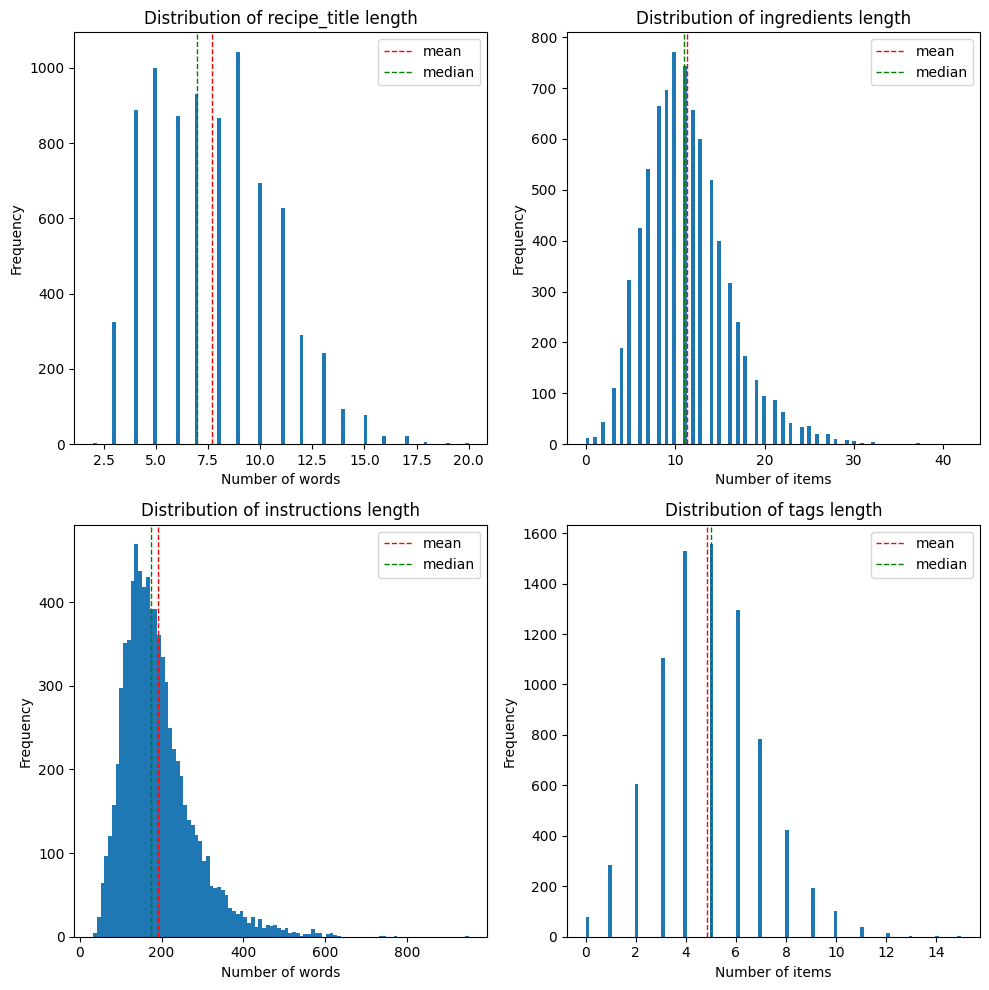

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Make a function to draw plot
def draw_subplot(df, col, axs, delimiter):
    # Handle non-string values (like NaN) by assigning them a length of 0.
    lengths = df[col].apply(lambda x: len(x.split(delimiter)) if isinstance(x, str) else 0)
    axs.hist(lengths, bins=100)
    if col == 'recipe_title' or col == 'instructions':
        axs.set_xlabel('Number of words')
    else:
        axs.set_xlabel('Number of items')
    axs.set_ylabel('Frequency')
    axs.set_title(f'Distribution of {col} length')

    # Add horizontal lines indicate mean and median
    axs.axvline(lengths.mean(), color='r', linestyle='dashed', linewidth= 1, label='mean')
    axs.axvline(lengths.median(), color='g', linestyle='dashed', linewidth= 1, label='median')
    axs.legend()

# Make subplot for them
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
draw_subplot(df, 'recipe_title', axs[0, 0], ' ')
draw_subplot(df, 'ingredients', axs[0, 1], '|')
draw_subplot(df, 'instructions', axs[1, 0], ' ')
draw_subplot(df, 'tags', axs[1, 1], '|')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [ ]:
# Number of unique ingredients and tags after split '|'
print('Number of unique ingredients:', df['ingredients'].apply(lambda x: len(x.split('|')) if isinstance(x, str) else 0).nunique())
print('Number of unique tags:', df['tags'].apply(lambda x: len(x.split('|')) if isinstance(x, str) else 0).nunique())

Number of unique ingredients: 39
Number of unique tags: 16


- Inspect `vote_count`, `rating` and `diet`.

In [ ]:
df.describe()

,vote_count,rating
count,8009.000000,8009.000000
mean,2268.004495,4.888621
std,3683.156570,0.077467
min,15.000000,3.175705
25%,494.000000,4.865031
50%,1050.000000,4.900553
75%,2487.000000,4.930000
max,80628.000000,5.000000


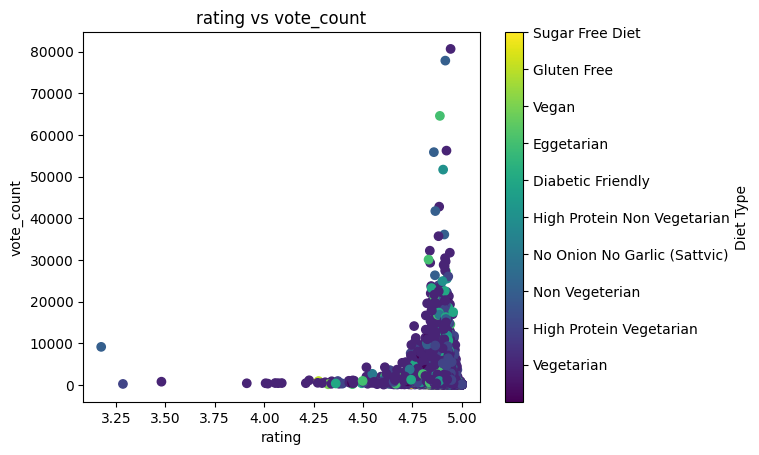

In [ ]:
# Get numerical representation of 'diet' column and unique categories
diet_codes, diet_categories = pd.factorize(df['diet'])

# Plot scatter vote_count and rating color by diet
plt.scatter(df['rating'], df['vote_count'], c=diet_codes) # Using 'viridis' colormap for distinct colors
plt.xlabel('rating')
plt.ylabel('vote_count')
plt.title('rating vs vote_count')

# Create a legend to map colors to diet categories
cbar = plt.colorbar(ticks=range(len(diet_categories)))
cbar.set_ticklabels(diet_categories)
cbar.set_label('Diet Type')
plt.show()

- Inspect `record_health`.

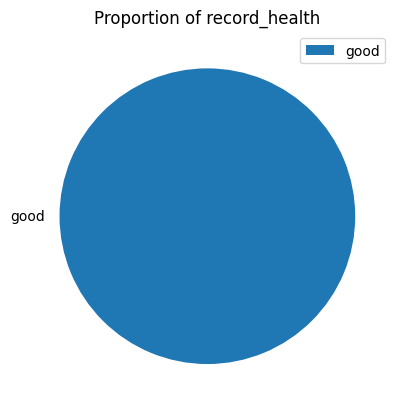

In [ ]:
plt.pie(df['record_health'].value_counts(), labels=df['record_health'].value_counts().index)
plt.title('Proportion of record_health')
plt.legend()
plt.show()

In [ ]:
# Drop record_health
df.drop('record_health', axis=1, inplace=True)

- Inspect categorical columns: `category`, `cuisine`, `course`.

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

def draw_pie(df, col, rows, cols):
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, "count"]
    fig.add_trace(
        go.Pie(labels=counts[col], values=counts["count"], name=col),
        row=rows, col=cols
    )

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "domain"}, {"type": "domain"}, {"type": "domain"}]],
    subplot_titles=("Category", "Cuisine", "Course"),
    horizontal_spacing=0.01,
    vertical_spacing=0.01
)

draw_pie(df, "category", 1, 1)
draw_pie(df, "cuisine", 1, 2) # Fun fact: Có 13 món Vietnamese!
draw_pie(df, "course", 1, 3)

fig.update_layout(title_text="Distribution charts", showlegend=False)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [ ]:
categories_unique = df['category'].unique() # có nhiều category khá dị, có thể drop bớt.
print(categories_unique)
print(len(categories_unique)) # Có tận 99 categories -> Quá nhiều.

['Pizza Recipes' 'Indian Curry Recipes' 'Mexican Recipes' 'Kofta Recipes'
 'Biryani Recipes' 'Homemade Jams, Sauce & Pesto Recipes'
 'Variety Rice (Mixed Rice/ Flavoured Rice Recipes)'
 'Indian Chinese Recipes' 'Cake Recipes' 'Sabzi Recipes'
 'Continental Party Appetizer & Starter Recipes' 'Fish Recipes'
 'Pasta Recipes' 'Pulao Recipes' 'Poriyal Recipes (South Indian Sabzi)'
 'Continental Food Recipes' 'Roti Recipes' 'Continental Breakfast Recipes'
 'Omelette Recipes' 'Mutton Recipes' 'Rasam Recipes' 'Puri Recipes'
 'Egg Recipes' 'Indian Homemade Masala Powder & Chutney Powder Recipes'
 'Indian Salad Recipes' 'Kuzhambu Recipes' 'Indian Chutney Recipes'
 'Dal Recipes' 'Salad Recipes' 'Paratha Recipes' 'Indian Snack Recipes'
 'Pancake Recipes' 'Kadhi Recipes' 'Scrambled Egg Recipe'
 'Thai Recipes,Malaysian & East Asian Recipes' 'Indian Raita Recipes'
 'Indian Non Veg Recipes' 'Sweet Recipes (Indian Mithai / Indian Dessert)'
 'Thoran Recipes' 'Dessert Recipes' 'Soup Recipes' 'Pachadi Reci

- Inspect `preptime` and `cooktime`

In [ ]:
# Trim the unit of time
df['prep_time'].value_counts()
df['prep_time'] = df['prep_time'].apply(lambda x: x.replace(' M', '') if isinstance(x, str) else x)
df['cook_time'] = df['cook_time'].apply(lambda x: x.replace(' M', '') if isinstance(x, str) else x)

# Convert prep_time and cook_time into int after filling NaN values with 0
df['prep_time'] = df['prep_time'].fillna(0).astype(int)
df['cook_time'] = df['cook_time'].fillna(0).astype(int)

In [ ]:
import plotly.express as px
# draw scatter plot with x=prep_time and y=cook_time and z=vote_count with plt express
fig = px.scatter_3d(df, x="prep_time", y="cook_time", z="vote_count", # chọn vote_count vì rating undependable
                    title="Scatter Plot of Prep Time vs Cook Time vs Vote Count", color='course')
fig.update_layout(height=750, width=1000)
fig.show()

- Inspect `author`.

In [ ]:
df['author'].value_counts() # Có 328 authors khác nhau. Wow!

,count
author,
Archana's Kitchen,2803
Archana Doshi,1293
Nithya Anantham,286
Jyothi Rajesh,200
Pooja Thakur,193
...,...
Archana,1
Mallika Chaudhary,1
Parthavi Pandya,1


- Inspect `url`.

In [ ]:
# print an url
print(df['url'][0]) # nó navigate tới 1 blog nấu ăn!

# Nhưng liệu url nào cũng mở được? -> Homework 3.

https://www.archanaskitchen.com/roasted-peppers-and-mushroom-tortilla-pizza-recipe


## **3. HOMEWORK DI LUÂN**
- ***Homework 1:*** Some charts seem unclear owing to the outlier. Help Chanh Hy `normalize` field `vote_count` manually. Write a function called `normalize()`.

In [ ]:
def normalize(column):
    min_val = column.min()
    max_val = column.max()
    normalized_col = (column - min_val) / (max_val - min_val)
    return normalized_col
df['normalized_vote_count'] = normalize(df['vote_count'])
df[['vote_count', 'normalized_vote_count']].head()

,vote_count,normalized_vote_count
0,434,0.005198
1,3423,0.042276
2,2091,0.025753
3,990,0.012095
4,345,0.004094


- ***Homework 2:*** By using `plt`, draw a static scatter graph between `vote_count` and `rating`. Just guess: is it linear?

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(x=df['rating'], y=df['normalized_vote_count'], alpha=0.5, color='blue')
plt.title('Relationship  of rating and vote count')
plt.xlabel('Rating')
plt.ylabel('Vote Count')
plt.show()
#non-linear
#concentrated in the bottom right corner --> lots of dishes that have good-rating but low vote counts

NameError: name 'df' is not defined

<Figure size 1000x600 with 0 Axes>

- ***Homework 3:*** Check if any `url` is invalid to open.

In [ ]:
import requests

def check_valid_url(url):
    try:
        response = requests.head(url, timeout=2)
        return response.status_code < 400
    except:
        return False
for i, url in enumerate(df['url'].head(8100)):
    if check_valid_url(url) == False: print(f"[{i}] {url}")

[281] https://www.archanaskitchen.com/carrot-pilaf
[394] https://www.archanaskitchen.com/chinese-style-sweet-and-spicy-broccoli-stir-fry-with-sausage-recipe
[479] https://www.archanaskitchen.com/chinese-bhel-recipe-crispy-noodle-salad
[555] https://www.archanaskitchen.com/kashmiri-modur-pulao-with-pomegranate-and-paneer-masala-curry-recipe
[671] https://www.archanaskitchen.com/cold-asian-noodle-salad-flavoured-with-peanuts-and-sesame
[698] https://www.archanaskitchen.com/gehun-ka-halwa-sheera-wheat-flour-pudding
[717] https://www.archanaskitchen.com/spaghetti-pasta-recipe-in-basil-pesto-sauce
[776] https://www.archanaskitchen.com/kashmiri-chicken-pulao-recipe
[886] https://www.archanaskitchen.com/thai-style-tofu-peanut-noodles
[998] https://www.archanaskitchen.com/broccoli-capsicum-pulao-recipe
[1238] https://www.archanaskitchen.com/gawar-phali-masala-sabzi-recipe-cluster-bean-gravy-sabzi
[1276] https://www.archanaskitchen.com/pori-urundai-puffed-rice-balls
[1277] https://www.archanask

In [ ]:
# 281, 394, 479, 555, 671, 698, 717, 776, 829, 886, 998, 1238,
print(type(df.iterrows()))
print(type(df['url'].head()))

<class 'generator'>
<class 'pandas.core.series.Series'>
